# Plot Autocorrelation

Here we plot the autocorrelation functions derived from the mean power spectral density of multiple voltage time series pixels, for various pump strengths.

In [ ]:
import os
import sys

import matplotlib.pyplot as plt
%matplotlib widget
import numpy as np
from tqdm import tqdm
import matplotlib.cm as cm
import matplotlib.colors as mcolors

# Define colors
color_a = '#9d6108'  # Example: Red
color_b = '#12776f'  # Example: Blue
color_c = '#a9ccc7'

# Create custom colormap
cmap_name = 'my_list'
custom_cmap = mcolors.LinearSegmentedColormap.from_list(cmap_name, [color_a, color_c, color_b])

# style
plt.rcParams['font.family'] = 'serif'
plt.rcParams['axes.formatter.useoffset'] = False
plt.rcParams['figure.constrained_layout.use'] = True
plt.rcParams['axes.labelsize'] = 16
plt.rcParams['font.size'] = 14
plt.rcParams['legend.fontsize'] = 16
plt.rcParams['legend.frameon'] = False


## Assign arrays for each autocorrelation and PSD file

In [176]:

pump_list = np.round(np.arange(0.09, 0.13, 0.005), 3)

found_pumps = []
found_autocorrs = []
found_PSDs = []

for p in pump_list:
    try:
        autocorr = np.loadtxt(
            fname=f'Time series data/autocorr_shift_rotating_frame-pump={p}',
            dtype=complex
        )

        PSD = np.loadtxt(
            fname = f'Time series data/PSD_shift_rotating_frame-pump={p}',
            dtype=complex
        )

        found_pumps.append(p)
        found_autocorrs.append(autocorr)
        found_PSDs.append(PSD)
    except FileNotFoundError:
        print(f"Skipping pump={p}: file not found.")
        continue

pump_list = np.array(found_pumps)   
autocorr_list = np.real(np.array(found_autocorrs))
PSD_list = np.real(np.array(found_PSDs))


Skipping pump=0.095: file not found.
Skipping pump=0.105: file not found.


## Time array

In [177]:
DF = 50e3
bw=200
n_samples_RW=401

t_arr = 1e6 * np.arange( - n_samples_RW // 2, n_samples_RW // 2, 1) /(DF * 2 * bw)

f_arr = np.linspace(-DF/2, DF/2, n_samples_RW) / 1e3

## Plot all autocorrelation graphs

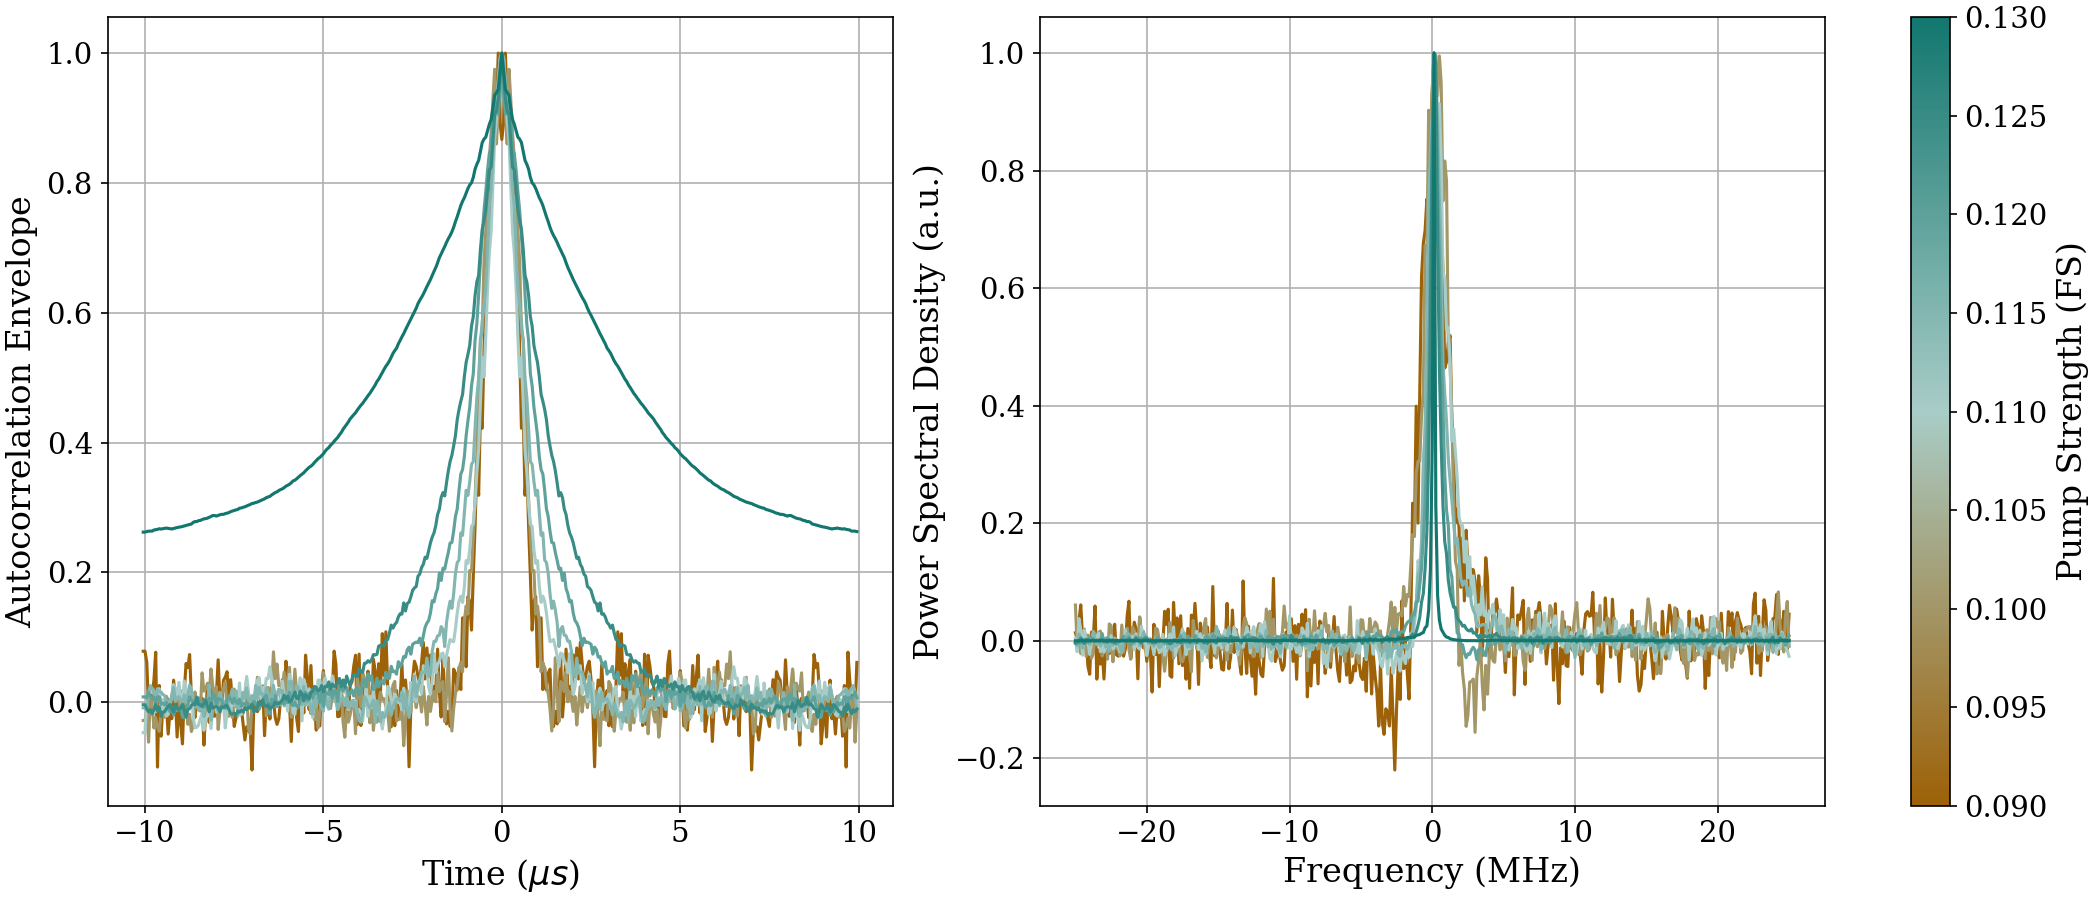

In [178]:



p_final = -1

cmap = custom_cmap
norm = mcolors.Normalize(vmin=pump_list[0], vmax=pump_list[p_final])

fig, ax = plt.subplots(
    nrows=1,
    ncols =2,
    figsize=(14, 6), 
    dpi=150
    )


ax1, ax2 = ax

for p_idx, p in enumerate(pump_list[:]):
    colors = cmap(norm(p))
    ax1.plot(
        t_arr, 
        autocorr_list[p_idx]/np.max(autocorr_list[p_idx]),
        color=colors,
        label= f'p = {p} FS'
    )

    PSD_list_symmetric = np.concatenate((PSD_list[p_idx][n_samples_RW//2:], PSD_list[p_idx][:n_samples_RW//2]))

    ax2.plot(
        f_arr,
        PSD_list_symmetric/np.max(PSD_list_symmetric),
        color=colors,
        label=f'p = {p} FS'
    )

# Autocorr plot settings
ax1.grid()
ax1.set_xlabel('Time ($\\mu s$)')
ax1.set_ylabel('Autocorrelation Envelope')
#ax1.set_title('Normalized Autocorrelation v.s. Pump Strength')


# PSD plot settings
ax2.grid()
ax2.set_xlabel('Frequency (MHz)')
ax2.set_ylabel('Power Spectral Density (a.u.)')

sm = cm.ScalarMappable(cmap=cmap, norm=norm)
sm.set_array([])  # needed for older matplotlib behavior

cbar = fig.colorbar(sm, ax=ax)
cbar.set_label("Pump Strength (FS)")


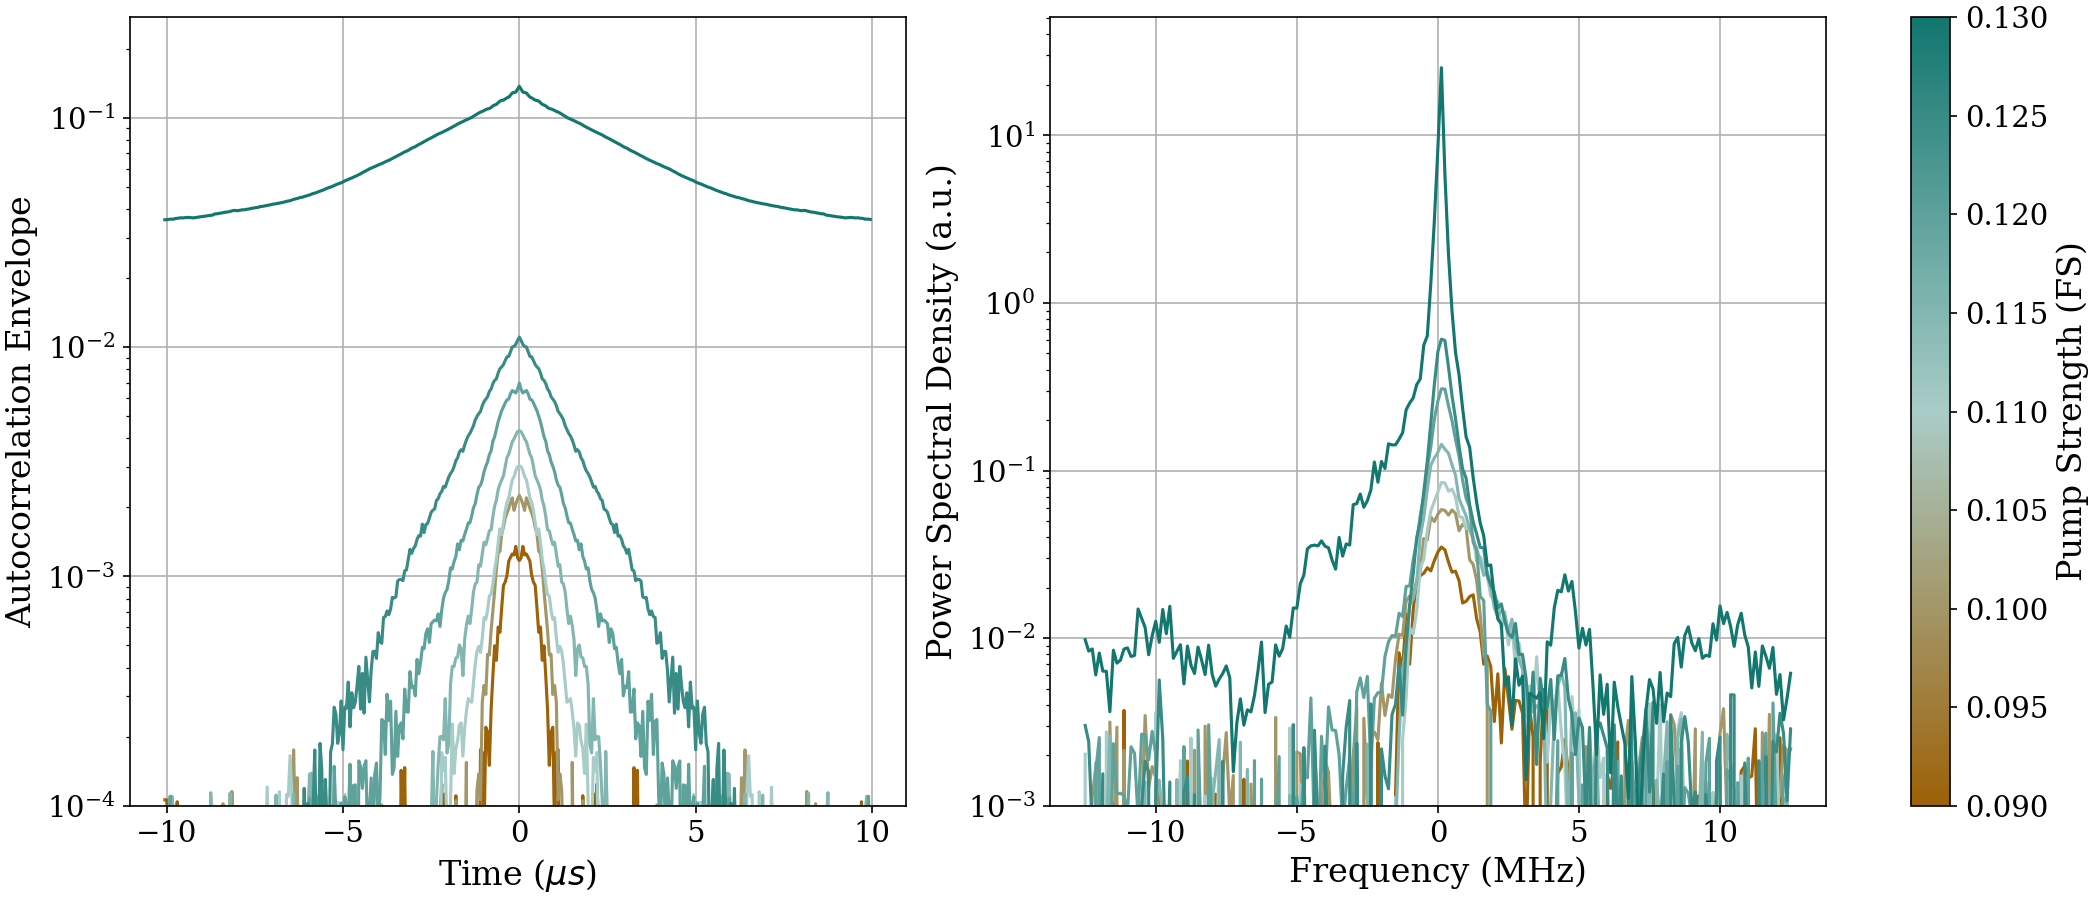

In [179]:
fig, ax = plt.subplots(
    nrows=1,
    ncols =2,
    figsize=(14, 6), 
    dpi=150
    )

# Freq range for psd plot
cutoff_idx = n_samples_RW // 4
indices = np.arange(cutoff_idx, n_samples_RW - cutoff_idx)

ax1, ax2 = ax

for p_idx, p in enumerate(pump_list[:]):
    colors = cmap(norm(p))
    ax1.semilogy(
        t_arr, 
        autocorr_list[p_idx],
        color=colors,
        label= f'p = {p} FS'
    )

    PSD_list_symmetric = np.concatenate((PSD_list[p_idx][n_samples_RW//2:], PSD_list[p_idx][:n_samples_RW//2]))

    ax2.semilogy(
        f_arr[indices],
        PSD_list_symmetric[indices],
        color=colors,
        label=f'p = {p} FS'
    )

# Autocorr plot settings
ax1.grid()
ax1.set_xlabel('Time ($\\mu s$)')
ax1.set_ylabel('Autocorrelation Envelope')
ax1.set_ylim(1e-4, 2*np.max(autocorr_list[p_final]))
#ax1.set_title('Normalized Autocorrelation v.s. Pump Strength')


# PSD plot settings
ax2.grid()
ax2.set_xlabel('Frequency (MHz)')
ax2.set_ylabel('Power Spectral Density (a.u.)')
ax2.set_ylim(1e-3, 2 * np.max(PSD_list[p_final]))

sm = cm.ScalarMappable(cmap=cmap, norm=norm)
sm.set_array([])  # needed for older matplotlib behavior

cbar = fig.colorbar(sm, ax=ax)
cbar.set_label("Pump Strength (FS)")


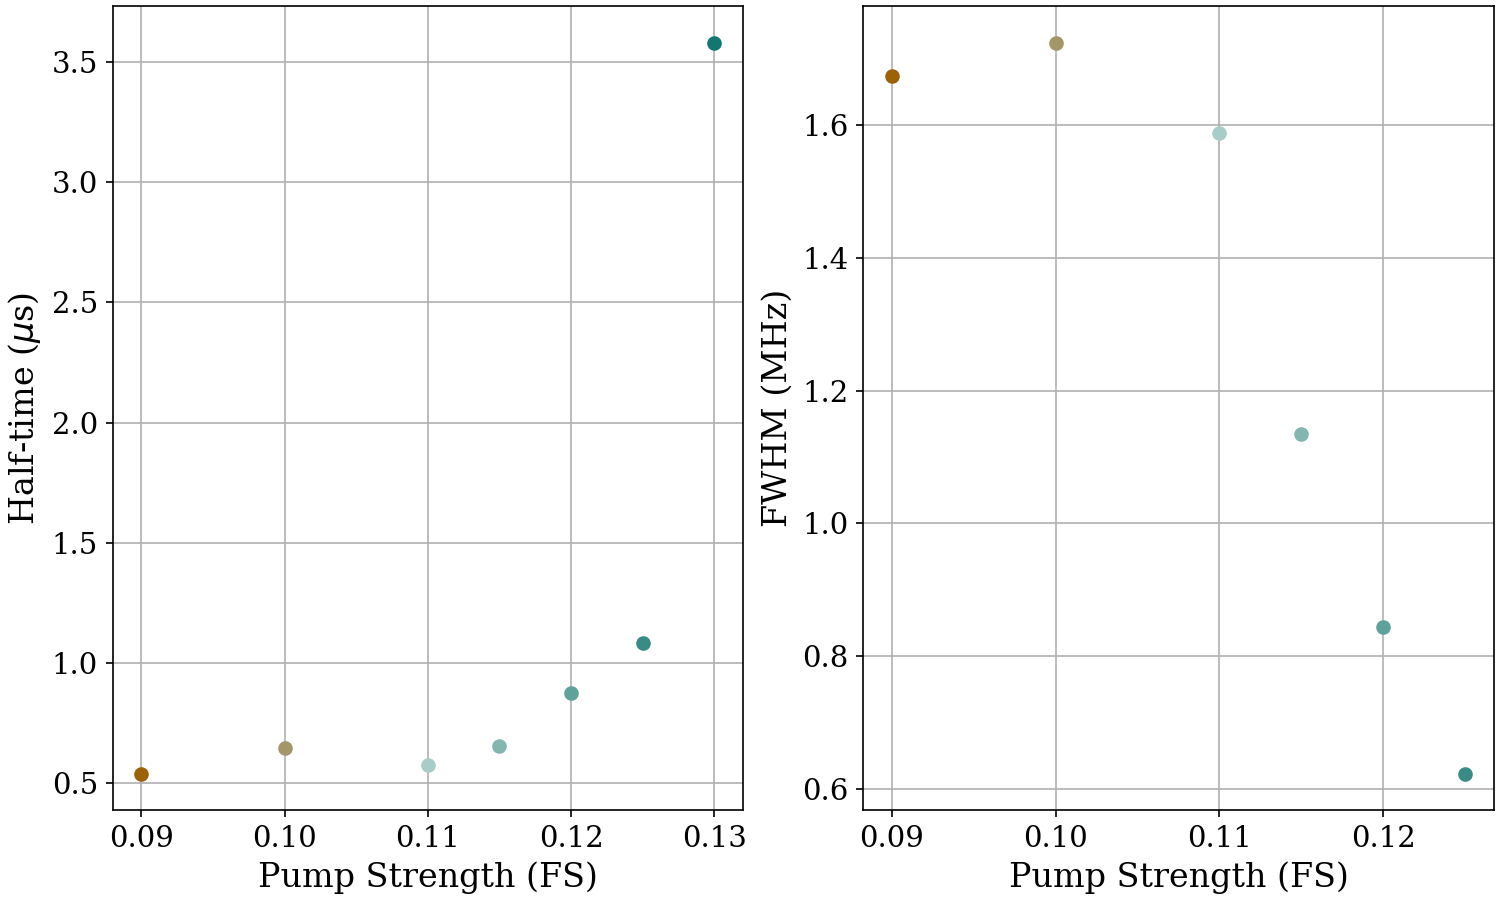

In [180]:
# --- Half-time of autocorrelation per pump ---
half_time_list = []
for p_idx in range(len(pump_list)):
    ac = autocorr_list[p_idx]
    t_pos = t_arr[n_samples_RW // 2:]
    ac_pos = ac[n_samples_RW // 2:]
    ac_norm = ac_pos / ac_pos[0]
    idx_half = np.searchsorted(-ac_norm, -0.5)
    if idx_half == 0 or idx_half >= len(t_pos):
        half_time_list.append(np.nan)
    else:
        t1, t2 = t_pos[idx_half - 1], t_pos[idx_half]
        v1, v2 = ac_norm[idx_half - 1], ac_norm[idx_half]
        t_half = t1 + (0.5 - v1) * (t2 - t1) / (v2 - v1)
        half_time_list.append(t_half)
half_time_list = np.array(half_time_list)

# --- FWHM of PSD per pump ---
fwhm_list = []
for p_idx in range(len(pump_list)):
    psd_sym = np.concatenate((PSD_list[p_idx][n_samples_RW // 2:],
                               PSD_list[p_idx][:n_samples_RW // 2]))
    psd_norm = psd_sym / np.max(psd_sym)
    half_max = 0.5
    left_half = psd_norm[:n_samples_RW // 2]
    right_half = psd_norm[n_samples_RW // 2:]
    above_left = np.where(left_half >= half_max)[0]
    below_right = np.where(right_half <= half_max)[0]
    if len(above_left) == 0 or len(below_right) == 0:
        fwhm_list.append(np.nan)
        continue
    idx_left = above_left[0]
    idx_right = n_samples_RW // 2 + below_right[0]
    f1, f2 = f_arr[idx_left - 1], f_arr[idx_left]
    v1, v2 = psd_norm[idx_left - 1], psd_norm[idx_left]
    f_left = f1 + (half_max - v1) * (f2 - f1) / (v2 - v1)
    f3, f4 = f_arr[idx_right - 1], f_arr[idx_right]
    v3, v4 = psd_norm[idx_right - 1], psd_norm[idx_right]
    f_right = f3 + (half_max - v3) * (f4 - f3) / (v4 - v3)
    fwhm_list.append(f_right - f_left)
fwhm_list = np.array(fwhm_list)

# --- Plot half-time and FWHM vs pump power ---
fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(10, 6), dpi=150,
                                constrained_layout=True)

for p_idx, p in enumerate(pump_list):
    color = cmap(norm(p))
    ax1.plot(p, half_time_list[p_idx], color=color, marker='o', ls='--', lw=1)
    ax2.plot(p, fwhm_list[p_idx],      color=color, marker='o', ls='--', lw=1)

ax1.set_xlabel('Pump Strength (FS)')
ax1.set_ylabel('Half-time ($\\mu$s)')
ax1.grid()

ax2.set_xlabel('Pump Strength (FS)')
ax2.set_ylabel('FWHM (MHz)')
ax2.grid()

# sm = cm.ScalarMappable(cmap=cmap, norm=norm)
# sm.set_array([])
# cbar = fig.colorbar(sm, ax=[ax1, ax2])
# cbar.set_label('Pump Strength (FS)')

plt.show()


/home/nanophys-meas/Desktop/Jai Master Thesis/venv/lib/python3.12/site-packages/ipympl/backend_nbagg.py:342: UserWarning: constrained_layout not applied because axes sizes collapsed to zero.  Try making figure larger or Axes decorations smaller.
  self.figure.savefig(buf, format='png', dpi='figure')


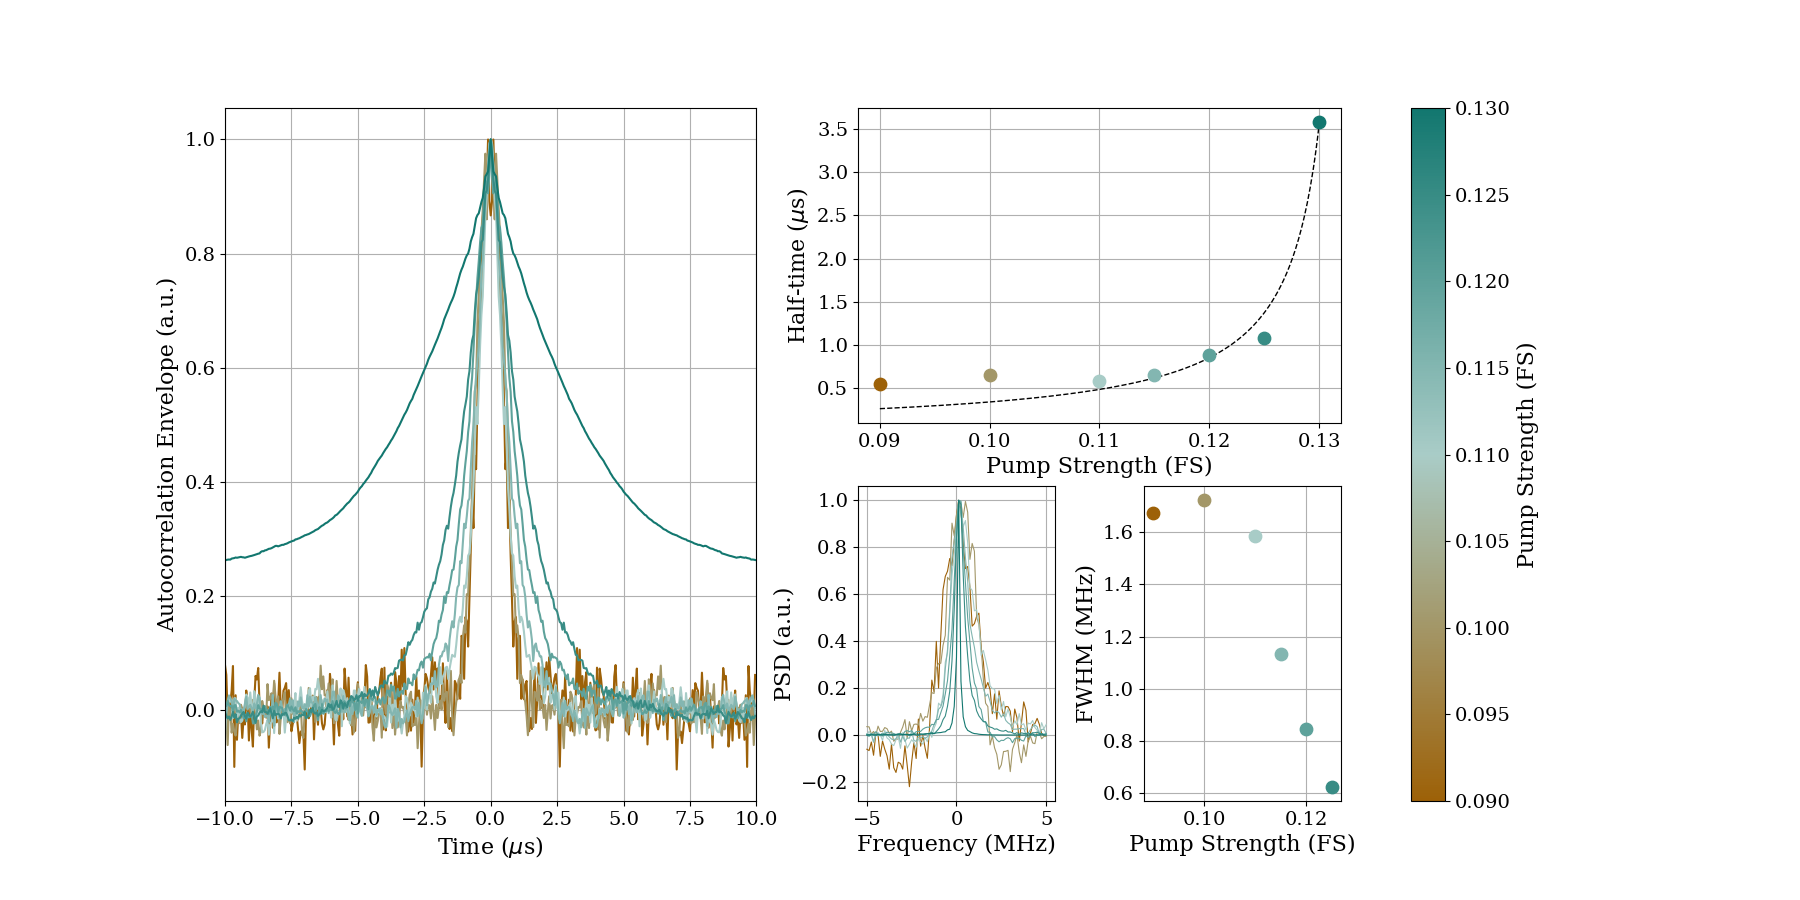

In [194]:
from scipy.optimize import curve_fit

# Exponential fit for half-time vs pump power
def exp_model(x, a, b):
    return a / (b - x)

valid = ~np.isnan(half_time_list)
try:
    popt, _ = curve_fit(exp_model, pump_list[valid], half_time_list[valid],
                        p0=[0.1, 1])
    pump_fit = np.linspace(pump_list[0], pump_list[-1], 300)
    half_time_fit = exp_model(pump_fit, *popt)
    fit_ok = True
except RuntimeError:
    fit_ok = False

# Build figure with nested gridspec
fig = plt.figure(figsize=(18, 9), dpi=100)
gs = fig.add_gridspec(2, 2, width_ratios=[1.1, 1])

ax_ac   = fig.add_subplot(gs[:, 0])       # autocorrelation, full height
ax_ht   = fig.add_subplot(gs[0, 1])       # half-time, top right
gs_br   = gs[1, 1].subgridspec(1, 2, wspace=0.45)
ax_psd  = fig.add_subplot(gs_br[0])       # PSD, bottom right left
ax_fwhm = fig.add_subplot(gs_br[1])       # FWHM, bottom right right

# --- Autocorrelation overlay ---
for p_idx, p in enumerate(pump_list):
    ax_ac.plot(t_arr,
               autocorr_list[p_idx] / np.max(autocorr_list[p_idx]),
               color=cmap(norm(p)))
ax_ac.set_xlabel('Time ($\\mu$s)')
ax_ac.set_ylabel('Autocorrelation Envelope (a.u.)')
ax_ac.grid()
ax_ac.set_xlim(-10, 10)

# --- Half-time scatter + exponential fit ---
for p_idx, p in enumerate(pump_list):
    ax_ht.scatter(p, half_time_list[p_idx], color=cmap(norm(p)), s=80, zorder=3)
if fit_ok:
    ax_ht.plot(pump_fit, half_time_fit, '--', lw=1, color = 'black',
               label=f'$a\\,e^{{bp}}$,  $a={popt[0]:.3f}$, $b={popt[1]:.1f}$')
    #ax_ht.legend()
ax_ht.set_xlabel('Pump Strength (FS)')
ax_ht.set_ylabel('Half-time ($\\mu$s)')
ax_ht.grid()

# --- PSD overlay ---

cutoff_idx = int(n_samples_RW * 0.4)
indices = np.arange(cutoff_idx, n_samples_RW - cutoff_idx)

for p_idx, p in enumerate(pump_list):
    psd_s = np.concatenate((PSD_list[p_idx][n_samples_RW // 2:],
                             PSD_list[p_idx][:n_samples_RW // 2]))
    ax_psd.plot(f_arr[indices], psd_s[indices]/np.max(psd_s[indices]), color=cmap(norm(p)), lw=0.8)

ax_psd.set_xlabel('Frequency (MHz)')
ax_psd.set_ylabel('PSD (a.u.)')
ax_psd.grid()

# --- FWHM scatter ---
for p_idx, p in enumerate(pump_list):
    ax_fwhm.scatter(p, fwhm_list[p_idx], color=cmap(norm(p)), s=80, zorder=3)
ax_fwhm.set_xlabel('Pump Strength (FS)')
ax_fwhm.set_ylabel('FWHM (MHz)')
ax_fwhm.grid()

# --- Shared colorbar to the right of everything ---
sm = cm.ScalarMappable(cmap=cmap, norm=norm)
sm.set_array([])
cbar = fig.colorbar(sm, ax=[ax_ac, ax_ht, ax_psd, ax_fwhm])
cbar.set_label('Pump Strength (FS)')

plt.show()


/tmp/ipykernel_192334/1605902056.py:50: UserWarning: No artists with labels found to put in legend.  Note that artists whose label start with an underscore are ignored when legend() is called with no argument.
  ax_ht.legend()
/home/nanophys-meas/Desktop/Jai Master Thesis/venv/lib/python3.12/site-packages/ipympl/backend_nbagg.py:342: UserWarning: constrained_layout not applied because axes sizes collapsed to zero.  Try making figure larger or Axes decorations smaller.
  self.figure.savefig(buf, format='png', dpi='figure')


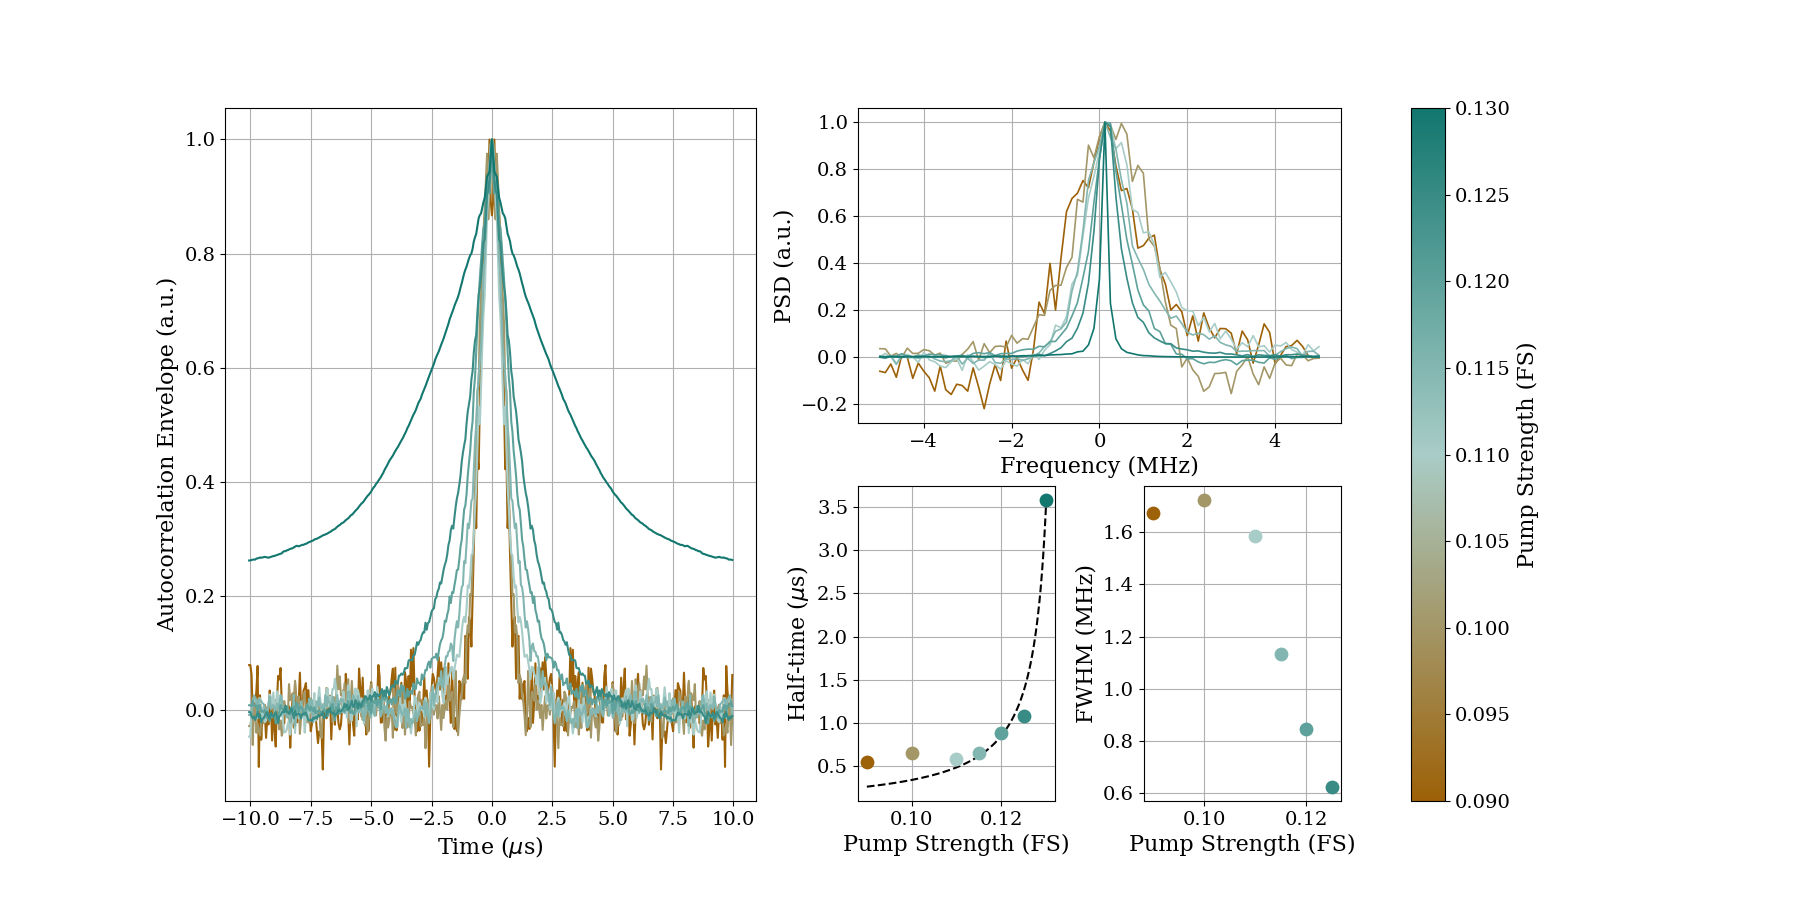

In [ ]:
from scipy.optimize import curve_fit

# Exponential fit for half-time vs pump power
def exp_model(x, a, b):
    return a / ( b - x )

valid = ~np.isnan(half_time_list)
try:
    popt, _ = curve_fit(exp_model, pump_list[valid], half_time_list[valid],
                        p0=[1, 1])
    pump_fit = np.linspace(pump_list[0], pump_list[-1], 300)
    half_time_fit = exp_model(pump_fit, *popt)
    fit_ok = True
except RuntimeError:
    fit_ok = False

# Build figure with nested gridspec
fig = plt.figure(figsize=(18, 9), dpi=100)
gs = fig.add_gridspec(2, 2, width_ratios=[1.1, 1])

ax_ac   = fig.add_subplot(gs[:, 0])       # autocorrelation, full height
ax_psd  = fig.add_subplot(gs[0, 1])       # PSD, top right
gs_br   = gs[1, 1].subgridspec(1, 2, wspace=0.45)
ax_ht   = fig.add_subplot(gs_br[0])       # half-time, bottom right left
ax_fwhm = fig.add_subplot(gs_br[1])       # FWHM, bottom right right

# --- Autocorrelation overlay ---
for p_idx, p in enumerate(pump_list):
    ax_ac.plot(t_arr,
               autocorr_list[p_idx] / np.max(autocorr_list[p_idx]),
               color=cmap(norm(p)))
ax_ac.set_xlabel('Time ($\\mu$s)')
ax_ac.set_ylabel('Autocorrelation Envelope (a.u.)')
ax_ac.grid()

# --- PSD overlay ---
for p_idx, p in enumerate(pump_list):
    psd_s = np.concatenate((PSD_list[p_idx][n_samples_RW // 2:],
                             PSD_list[p_idx][:n_samples_RW // 2]))
    ax_psd.plot(f_arr[indices], psd_s[indices]/np.max(psd_s[indices]), color=cmap(norm(p)), lw=1.2)
ax_psd.set_xlabel('Frequency (MHz)')
ax_psd.set_ylabel('PSD (a.u.)')
ax_psd.grid()

# --- Half-time scatter + exponential fit ---
for p_idx, p in enumerate(pump_list):
    ax_ht.scatter(p, half_time_list[p_idx], color=cmap(norm(p)), s=80, zorder=3)
if fit_ok:
    ax_ht.plot(pump_fit, half_time_fit, 'k--', lw=1.5,)
    ax_ht.legend()
ax_ht.set_xlabel('Pump Strength (FS)')
ax_ht.set_ylabel('Half-time ($\\mu$s)')
ax_ht.grid()

# --- FWHM scatter ---
for p_idx, p in enumerate(pump_list):
    ax_fwhm.scatter(p, fwhm_list[p_idx], color=cmap(norm(p)), s=80, zorder=3)
ax_fwhm.set_xlabel('Pump Strength (FS)')
ax_fwhm.set_ylabel('FWHM (MHz)')
ax_fwhm.grid()

# --- Shared colorbar to the right of everything ---
sm = cm.ScalarMappable(cmap=cmap, norm=norm)
sm.set_array([])
cbar = fig.colorbar(sm, ax=[ax_ac, ax_psd, ax_ht, ax_fwhm])
cbar.set_label('Pump Strength (FS)')

plt.show()
